# Copy-suppression search in Pythia-410M-deduped @ step143000 — Path C registered

**Pre-registered pilot anchor.** Per `HYPOTHESIS.md` §"Pilot decision rule", we apply the McDougall two-criterion detector (QK > 0.3 AND OV < 0) to all 384 heads of Pythia-410M-deduped at the final checkpoint, on the canonical Wikipedia-derived corpus. Decision rule:

1. ≥3 heads pass + qualitatively confirmed → Path A.
2. 1-2 heads pass + qualitatively confirmed → Path A with caveat.
3. 0 heads pass, OR numerically-passing heads fail qualitative inspection → Path C.
4. Tie / ambiguous → Path C.

**Result (locked in `PILOT_RESULTS.md`).** 1 head numerically passes strict (L2H8: QK=0.328, OV=-0.023) — the *Weak positive* numerical state. Day 4 qualitative inspection: L2H8's attention pattern is textbook duplicate-attending (0.91 attention back to prior occurrence at the rank-1 worked-example position), but **corpus-wide ablation of L2H8 lowers duplicate-token logits by 0.009 — the opposite direction of suppression**. L2H8 is a previous-token / induction-precursor head, not a copy-suppression head. By decision-rule path 3, the project pivots to Path C: **the third motif of the H1 ordering claim becomes S-inhibition, not copy-suppression** (per `HYPOTHESIS.md` §"Pivot hypothesis (H1-C)").

This notebook documents that finding end-to-end:

**Part A — detection.** Load anchor parquet; visualize the (QK, OV) plane for all 384 heads; identify L2H8 as the only strict-criterion-passing head; rank supplementary candidates by most-negative OV among heads with QK ≥ 0.05.

**Part B — proof of L2H8's behavior.** Data-driven worked example from the per-position OV cache; bird's-eye and focused attention plots; single-position + corpus-wide ablation matrix (d-logit × NLL × single × corpus per Q8 of design grilling).

**Part C — contrast with GPT-2 L10H7.** Side-by-side ablation: L10H7 (known-positive) corpus-wide d-logit = +0.032 (suppression direction); L2H8 corpus-wide d-logit = -0.009 (opposite). Different mechanisms; Pythia has no McDougall-style copy-suppression heads.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn.functional import log_softmax
from transformer_lens import HookedTransformer

from notebooks._lib.sweep_io import read_long, to_wide
from src.detectors.copy_suppression import _build_dup_index
from src.utils.corpus_io import load_corpus
from src.utils.pythia_loader import load_pythia

torch.set_grad_enabled(False)

QK_STRICT = 0.3
OV_THRESHOLD = 0.0

ANCHOR_PARQUET = REPO / 'data' / 'pilot' / 'copy_suppression_pythia_410m_step143000.parquet'
ANCHOR_NPZ = REPO / 'data' / 'pilot' / 'copy_suppression_pythia_410m_step143000_per_position.npz'

In [2]:
def upper_tri_mask(n: int) -> np.ndarray:
    return torch.triu(torch.ones(n, n), diagonal=1).bool().numpy()

def make_ablate_hook(layer: int, head: int):
    name = f'blocks.{layer}.attn.hook_z'
    def fn(z, hook):
        z[:, :, head, :] = 0
        return z
    return (name, fn)

## Part A — detection

### Load anchor scores and per-position OV cache

In [3]:
df = read_long(ANCHOR_PARQUET)
wide = to_wide(df, index_cols=('size','step','layer','head'))
wide['passes_strict'] = (wide['copy_suppression_qk'] > QK_STRICT) & (wide['copy_suppression_ov'] < OV_THRESHOLD)
n_layers = int(wide['layer'].max() + 1)
n_heads = int(wide['head'].max() + 1)
print(f'anchor shape: n_layers={n_layers}, n_heads={n_heads}')
print(f'eligible duplicate positions: see PILOT_RESULTS.md (2769)')
print(f'heads passing strict criterion: {wide["passes_strict"].sum()} of {len(wide)}')

z = np.load(ANCHOR_NPZ)
per_position_ov = z['per_position_ov']  # (n_eligible, n_layers, n_heads)
per_position_meta = z['per_position_meta']  # (n_eligible, 2)
print(f'per-position OV cache: shape={per_position_ov.shape}, n_eligible={len(per_position_meta)}')

anchor shape: n_layers=24, n_heads=16
eligible duplicate positions: see PILOT_RESULTS.md (2769)
heads passing strict criterion: 1 of 384
per-position OV cache: shape=(2769, 24, 16), n_eligible=2769


### (QK, OV) scatter for all 384 heads

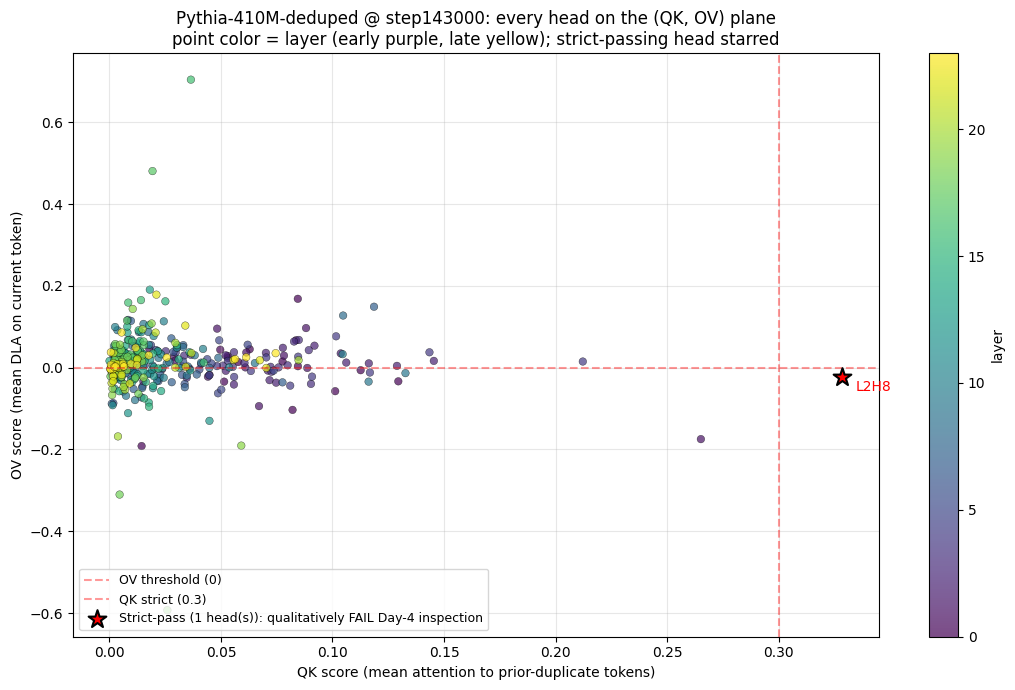

In [4]:
qk = wide['copy_suppression_qk'].values
ov = wide['copy_suppression_ov'].values
layers = wide['layer'].values
heads = wide['head'].values

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(qk, ov, c=layers, cmap='viridis', s=30, alpha=0.7,
                     edgecolor='k', linewidth=0.3)
ax.axhline(OV_THRESHOLD, color='red', linestyle='--', alpha=0.4, label='OV threshold (0)')
ax.axvline(QK_STRICT, color='red', linestyle='--', alpha=0.4, label=f'QK strict ({QK_STRICT})')

# Highlight strict-passing head(s) and the qualitative-fail outcome.
strict_mask = wide['passes_strict'].values
if strict_mask.any():
    ax.scatter(qk[strict_mask], ov[strict_mask], s=180, marker='*',
               color='red', edgecolor='black', linewidth=1.5, zorder=10,
               label=f'Strict-pass ({strict_mask.sum()} head(s)): qualitatively FAIL Day-4 inspection')
    for li, hi in zip(layers[strict_mask], heads[strict_mask]):
        ix = np.where((layers == li) & (heads == hi))[0][0]
        ax.annotate(f'L{int(li)}H{int(hi)}', xy=(qk[ix], ov[ix]),
                    xytext=(10, -10), textcoords='offset points', color='red', fontsize=10)

ax.set_xlabel('QK score (mean attention to prior-duplicate tokens)')
ax.set_ylabel('OV score (mean DLA on current token)')
ax.set_title('Pythia-410M-deduped @ step143000: every head on the (QK, OV) plane\n'
             'point color = layer (early purple, late yellow); strict-passing head starred')
ax.grid(alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
plt.colorbar(scatter, ax=ax, label='layer')
plt.tight_layout()
plt.show()

**Reading the scatter.** The lower-right quadrant (high QK, very negative OV) is where copy-suppression heads should live. On Pythia-410M @ step143000, this quadrant is essentially empty:

- Heads with high QK (right side) cluster around OV ≈ 0 — duplicate-attending but not suppressing.
- Heads with very negative OV (bottom) are mid-to-late layers (yellow) but have low QK (< 0.05) — not attending strongly to prior duplicates.
- Only L2H8 squeaks past both thresholds, with marginal OV (-0.023). The qualitative inspection in `PILOT_RESULTS.md` § Manual qualitative inspection shows this is functionally a previous-token head, not a copy-suppression head.

Compare to GPT-2 small on the same canonical corpus (`copy_suppression_proof.ipynb`): L10H7 sits at OV ≈ -0.8, with QK ≈ 0.02 — strong-OV-but-low-QK by the same raw-text dilution. Pythia's analog of L10H7's *position* (low-QK, very-negative-OV) is L18H15 (QK=0.026, OV=-0.593) but it doesn't pass the strict criterion either.

### Top-10 rankings

In [5]:
wide_sorted_ov = wide.sort_values('copy_suppression_ov').reset_index(drop=True)
wide_sorted_qk = wide.sort_values('copy_suppression_qk', ascending=False).reset_index(drop=True)

print('Top-10 heads by most-negative OV (strongest suppression direction, head-level mean):')
for _, r in wide_sorted_ov.head(10).iterrows():
    qk_v = r['copy_suppression_qk']; ov_v = r['copy_suppression_ov']
    star = '  <-- passes strict' if (qk_v > QK_STRICT and ov_v < 0) else ''
    print(f"  L{int(r['layer']):2d}H{int(r['head']):2d}: QK={qk_v:.3f} OV={ov_v:+.3f}{star}")

print('\nTop-10 heads by QK (strongest attention to prior duplicates):')
for _, r in wide_sorted_qk.head(10).iterrows():
    qk_v = r['copy_suppression_qk']; ov_v = r['copy_suppression_ov']
    star = '  <-- passes strict' if (qk_v > QK_STRICT and ov_v < 0) else ''
    print(f"  L{int(r['layer']):2d}H{int(r['head']):2d}: QK={qk_v:.3f} OV={ov_v:+.3f}{star}")

Top-10 heads by most-negative OV (strongest suppression direction, head-level mean):
  L18H15: QK=0.026 OV=-0.593
  L18H 5: QK=0.005 OV=-0.310
  L 0H 9: QK=0.014 OV=-0.192
  L19H 3: QK=0.059 OV=-0.191
  L 1H 4: QK=0.265 OV=-0.175
  L20H12: QK=0.004 OV=-0.168
  L12H 1: QK=0.045 OV=-0.130
  L12H12: QK=0.008 OV=-0.111
  L 0H15: QK=0.082 OV=-0.103
  L15H 7: QK=0.018 OV=-0.095

Top-10 heads by QK (strongest attention to prior duplicates):
  L 2H 8: QK=0.328 OV=-0.023  <-- passes strict
  L 1H 4: QK=0.265 OV=-0.175
  L 4H 8: QK=0.212 OV=+0.015
  L 2H 0: QK=0.145 OV=+0.017
  L 4H15: QK=0.143 OV=+0.038
  L 9H 1: QK=0.133 OV=-0.013
  L 0H11: QK=0.130 OV=-0.033
  L 2H 9: QK=0.129 OV=+0.005
  L 7H 0: QK=0.119 OV=+0.149
  L 4H14: QK=0.117 OV=-0.012


### select_proof_target — branching helper per Q6

The Day 3 design grilling pre-committed to a deterministic branching rule for the proof target:
- **Outcome 1** (≥1 strict candidate): top-3 strict candidates by most-negative OV.
- **Outcome 2** (calibrated candidates only): dropped — calibrated scheme failed validation.
- **Outcome 3** (empty): GPT-2 L10H7 reference + framing as 'we looked, here's the absence'.

In the registered Path C universe, we have outcome 1 numerically (L2H8 passes strict) with a qualitative-fail verdict. Branching rule still selects L2H8 as the proof target, and Part C contrasts its behavior against GPT-2 L10H7 to make the Path-C registration cleanly visible.

In [6]:
def select_proof_target(wide_df):
    strict = wide_df[wide_df['passes_strict']].sort_values('copy_suppression_ov')
    if len(strict) > 0:
        top_heads = [(int(r['layer']), int(r['head'])) for _, r in strict.head(3).iterrows()]
        # Control: lowest |QK|+|OV| across all heads
        s = (wide_df['copy_suppression_qk'].abs() + wide_df['copy_suppression_ov'].abs())
        ctl_idx = s.idxmin()
        ctl = (int(wide_df.loc[ctl_idx,'layer']), int(wide_df.loc[ctl_idx,'head']))
        frame = ('Outcome 1 — strict candidate(s) found numerically; '
                 'qualitative inspection per PILOT_RESULTS.md determines whether they are '
                 'real copy-suppression heads')
        return top_heads, ctl, frame
    # Outcome 3 fallback: GPT-2 reference
    return [(10, 7)], (0, 0), 'Outcome 3 — empty in Pythia; using GPT-2 L10H7 reference'

TOP_HEADS, CONTROL, FRAME = select_proof_target(wide)
print(f'Frame: {FRAME}')
print(f'TOP_HEADS = {TOP_HEADS}')
print(f'CONTROL = {CONTROL}')

Frame: Outcome 1 — strict candidate(s) found numerically; qualitative inspection per PILOT_RESULTS.md determines whether they are real copy-suppression heads
TOP_HEADS = [(2, 8)]
CONTROL = (21, 1)


## Part B — proof of L2H8's behavior

### Load Pythia-410M-deduped + canonical corpus

Need the model for ablation forward passes and attention-pattern caching. Same corpus the anchor detector ran on, so worked-example positions index into the same passages.

In [7]:
model = load_pythia('410m', step=143000)
device = next(model.parameters()).device
n_layers, n_heads = int(model.cfg.n_layers), int(model.cfg.n_heads)
passages = load_corpus()
sequences = [model.to_tokens(p.text)[0].cpu() for p in passages]
print(f'model loaded: device={device}, n_layers={n_layers}, n_heads={n_heads}')
print(f'corpus: {len(sequences)} passages')

/Users/cberg/Documents/Emergence_Research/pythia-motif-emergence/.venv/lib/python3.12/site-packages/transformer_lens/config/HookedTransformerConfig.py:341: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.11.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m-deduped into HookedTransformer
model loaded: device=mps:0, n_layers=24, n_heads=16
corpus: 40 passages


### Data-driven worked example — top-3 positions where L2H8 fires hardest

Q7 design rule: sort all eligible corpus positions by per-position OV ascending; the rank-1 position is the one where the head's per-position OV contribution is most-negative — i.e., where it would suppress most strongly *if* the OV criterion captured the real mechanism.

In [8]:
L_T, H_T = TOP_HEADS[0]  # rank-1 strict candidate
ov_th = per_position_ov[:, L_T, H_T]
rank_order = np.argsort(ov_th)

print(f'top-3 corpus positions for L{L_T}H{H_T} (most-negative per-position OV):')
for r in range(3):
    k = int(rank_order[r])
    p_idx, pos = int(per_position_meta[k][0]), int(per_position_meta[k][1])
    seq = sequences[p_idx]
    tok_id = int(seq[pos].item())
    tok_str = model.to_string([tok_id])
    lo = max(0, pos - 5); hi = min(len(seq), pos + 3)
    surrounding = model.to_string(seq[lo:hi].tolist())
    print(f'  rank {r+1}: passage {p_idx} ({passages[p_idx].title!r}), pos {pos}')
    print(f'           token = {tok_str!r}, OV = {ov_th[k]:+.3f}')
    print(f'           context = ...{surrounding!r}...')

# Lock the rank-1 worked example for visual analysis below.
K = int(rank_order[0])
EX_P_IDX = int(per_position_meta[K][0])
EX_POS = int(per_position_meta[K][1])
EX_TOKENS = sequences[EX_P_IDX].clone()
EX_TOK_ID = int(EX_TOKENS[EX_POS].item())
EX_TOK_STR = model.to_string([EX_TOK_ID])
EX_TITLE = passages[EX_P_IDX].title
EX_STR_TOKENS = model.to_str_tokens(passages[EX_P_IDX].text)
print(f'\nworked example locked: passage={EX_TITLE!r}, pos={EX_POS}, '
      f'token={EX_TOK_STR!r}, per-position OV={ov_th[K]:+.3f}')

top-3 corpus positions for L2H8 (most-negative per-position OV):
  rank 1: passage 14 ('Stonehenge'), pos 115
           token = ' Inside', OV = -0.693
           context = ...' smaller bluestones. Inside, these'...
  rank 2: passage 29 ('Volcano'), pos 150
           token = ' convergent', OV = -0.515
           context = ...'ive whereas those resulting from convergent tect'...
  rank 3: passage 21 ('Quantum mechanics'), pos 113
           token = ' Classical', OV = -0.511
           context = ...' subatomic) scales. Classical mechanics can'...

worked example locked: passage='Stonehenge', pos=115, token=' Inside', per-position OV=-0.693


### Bird's-eye attention patterns on the worked-example passage

All 384 heads (24 × 16) plotted with upper-triangular masking. Watch for off-diagonal attention from later positions back to earlier occurrences of the same token — the QK signature shared by induction *and* copy-suppression. L2H8 is highlighted in red.

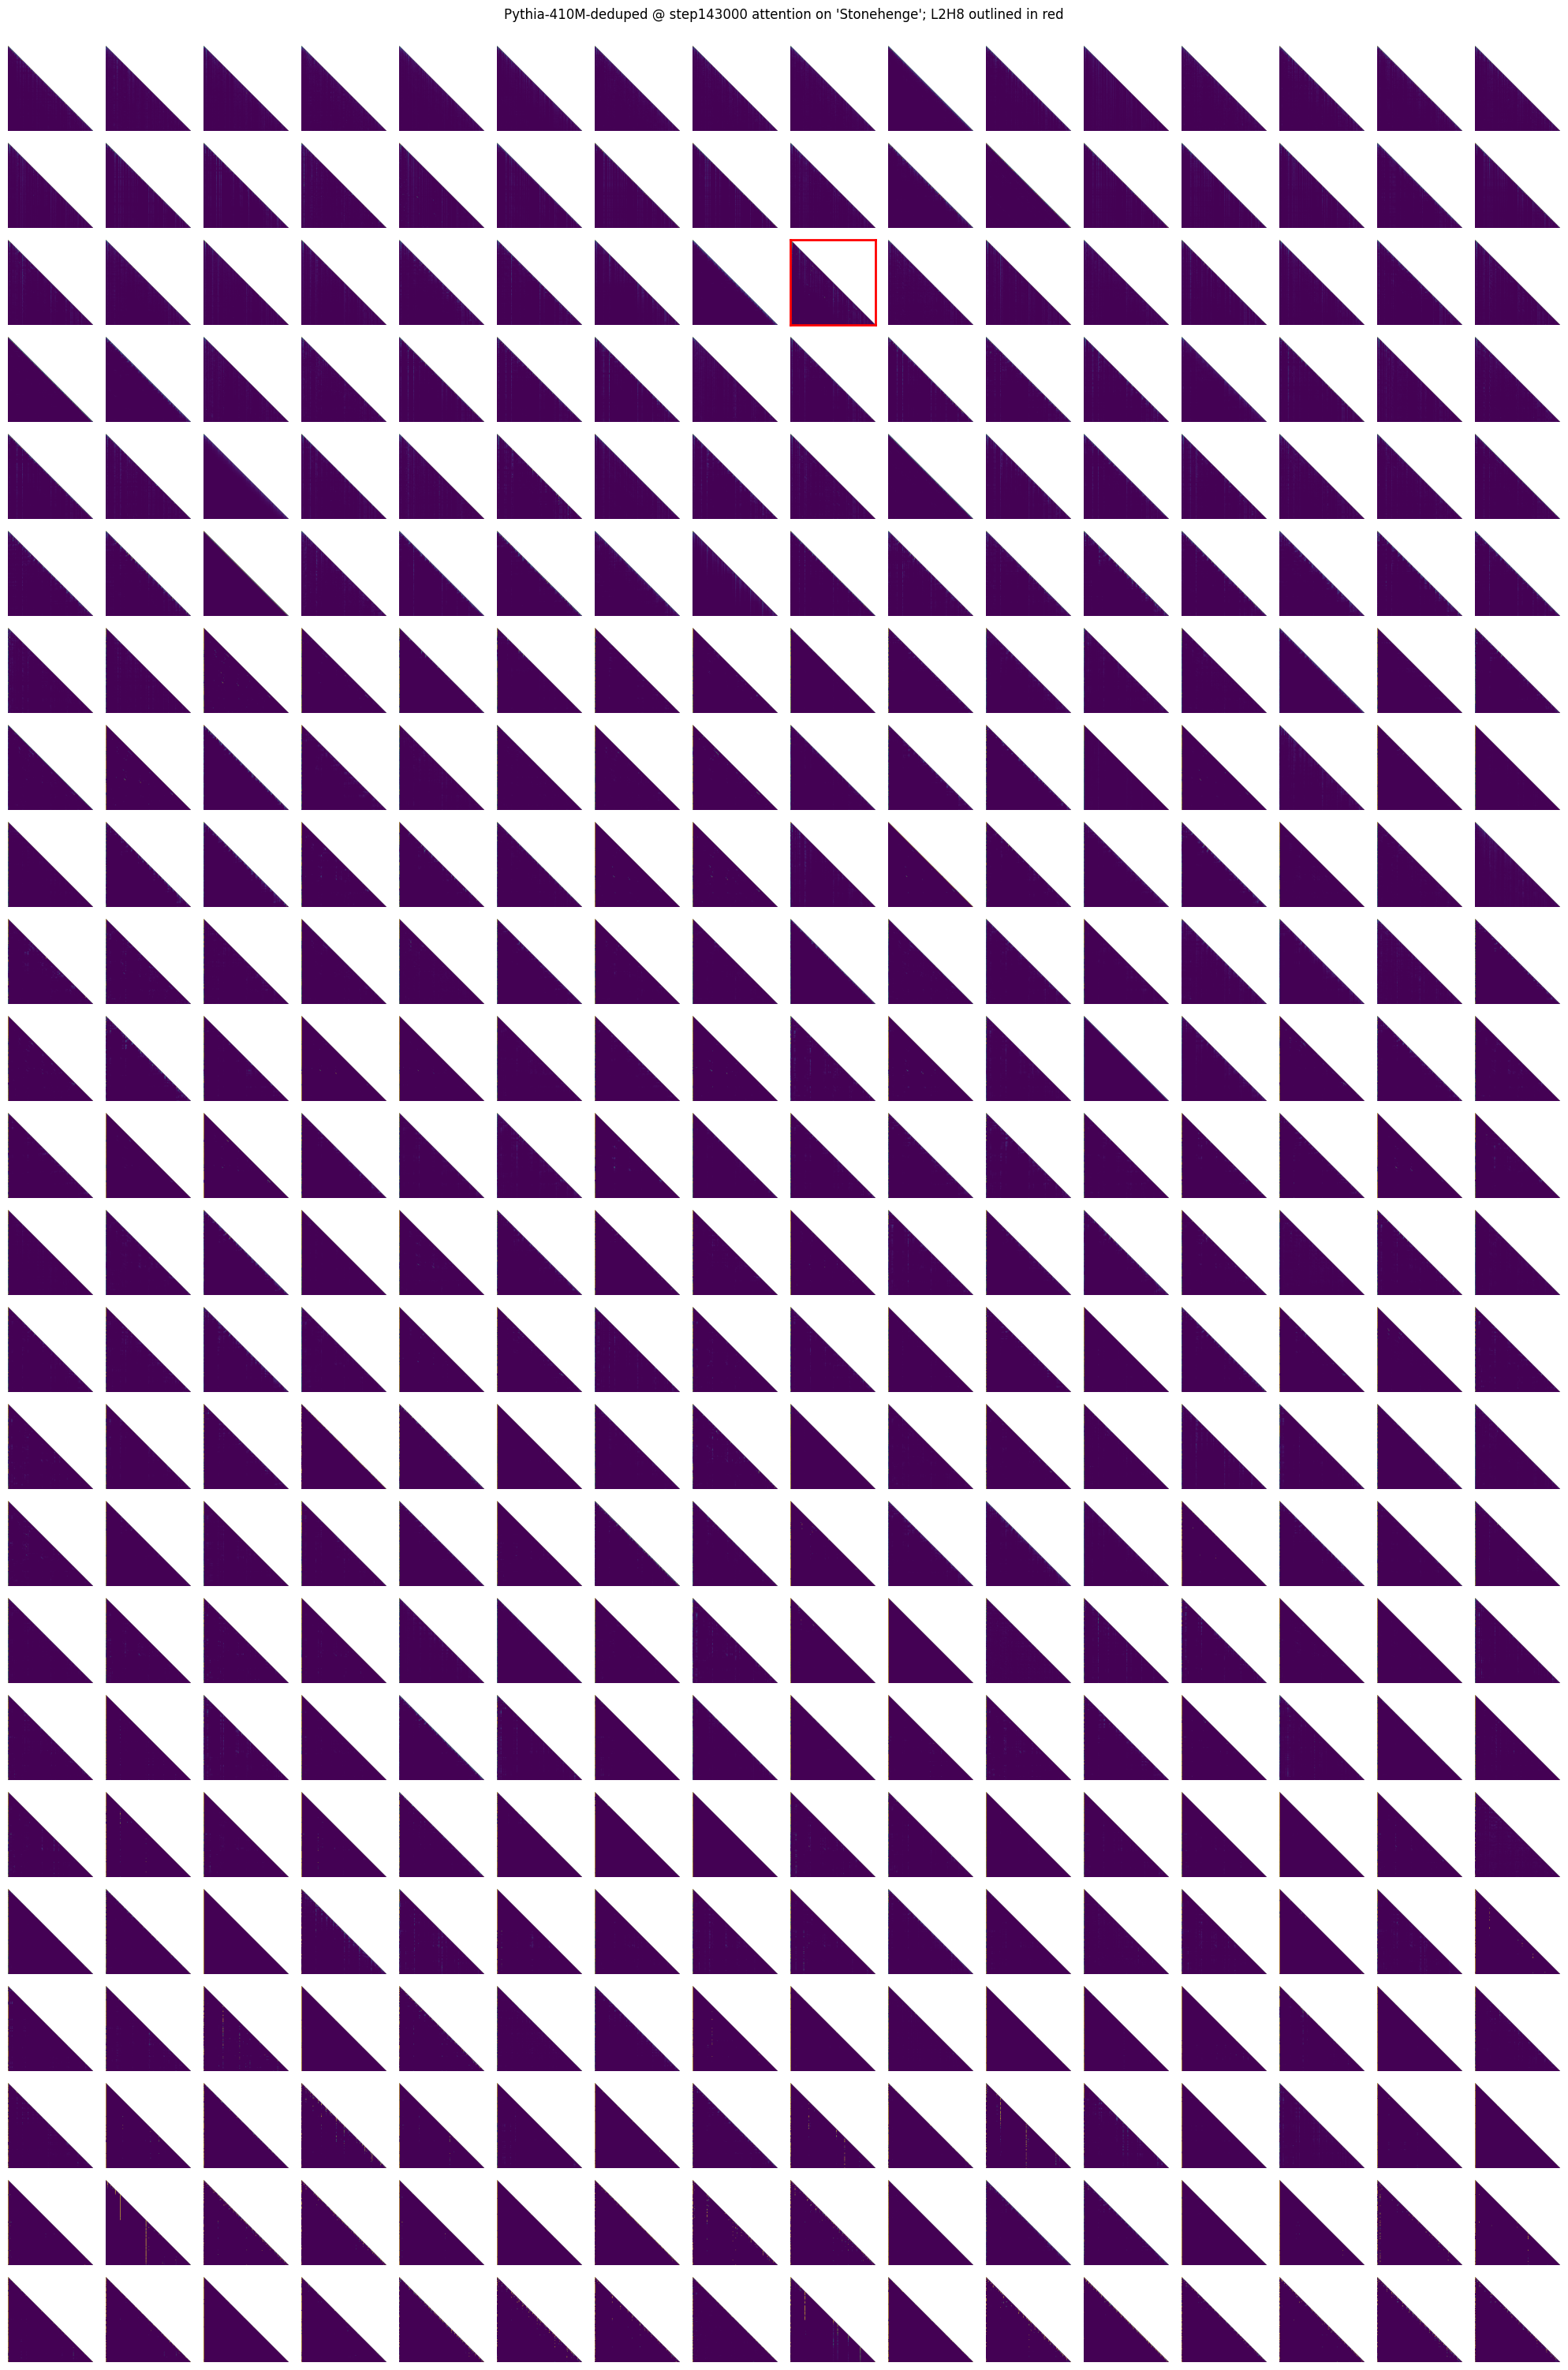

In [9]:
tokens_2d = EX_TOKENS.unsqueeze(0).to(device)
_, attn_cache = model.run_with_cache(
    tokens_2d, names_filter=lambda n: n.endswith('hook_pattern'), return_type=None
)
n_tok = len(EX_STR_TOKENS)
tri_mask = upper_tri_mask(n_tok)

fig = plt.figure(figsize=(20, 30))
for layer in range(n_layers):
    pat_layer = attn_cache[f'blocks.{layer}.attn.hook_pattern']
    for h in range(n_heads):
        ax = fig.add_subplot(n_layers, n_heads, n_heads * layer + h + 1)
        a = pat_layer[0, h, :n_tok, :n_tok].detach().cpu().float().numpy()
        a_masked = np.ma.masked_array(a, tri_mask)
        ax.imshow(a_masked)
        ax.axis('off')
        if (layer, h) == (L_T, H_T):
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Pythia-410M-deduped @ step143000 attention on {EX_TITLE!r}; '
             f'L{L_T}H{H_T} outlined in red', y=1.0)
plt.tight_layout()
plt.show()

### Focused — L2H8 vs control with token labels

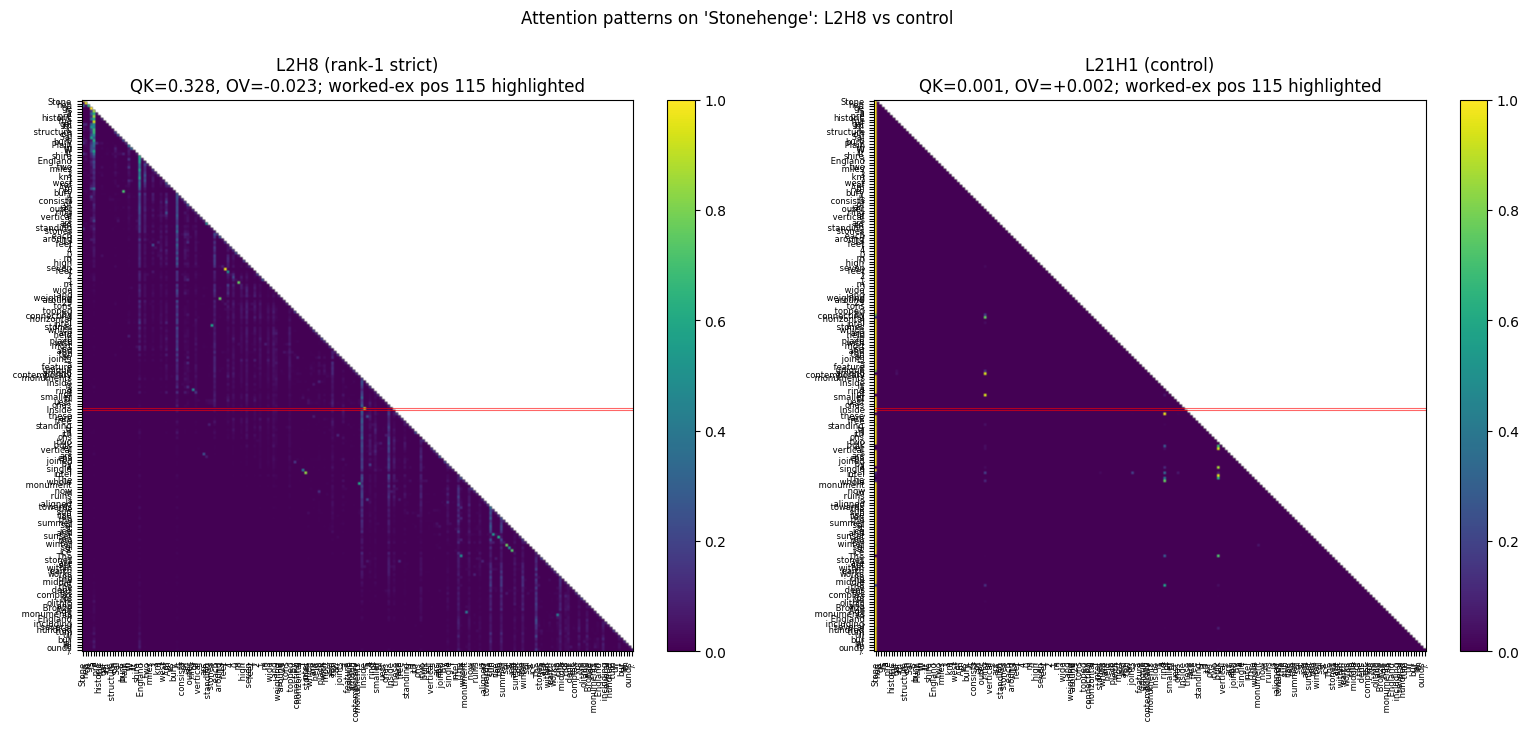

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (layer, head) in zip(axes, [(L_T, H_T), CONTROL]):
    pat = attn_cache[f'blocks.{layer}.attn.hook_pattern'][0, head, :n_tok, :n_tok]
    a = pat.detach().cpu().float().numpy()
    a_masked = np.ma.masked_array(a, tri_mask)
    label_extra = ' (rank-1 strict)' if (layer, head) == (L_T, H_T) else ' (control)'
    im = ax.imshow(a_masked)
    ax.set_xticks(range(n_tok))
    ax.set_yticks(range(n_tok))
    ax.set_xticklabels(EX_STR_TOKENS, rotation=90, fontsize=6)
    ax.set_yticklabels(EX_STR_TOKENS, fontsize=6)
    ax.axhline(EX_POS - 0.5, color='red', linewidth=0.8, alpha=0.6)
    ax.axhline(EX_POS + 0.5, color='red', linewidth=0.8, alpha=0.6)
    qk_v = float(wide[(wide['layer']==layer) & (wide['head']==head)]['copy_suppression_qk'].iloc[0])
    ov_v = float(wide[(wide['layer']==layer) & (wide['head']==head)]['copy_suppression_ov'].iloc[0])
    ax.set_title(f'L{layer}H{head}{label_extra}\n'
                 f'QK={qk_v:.3f}, OV={ov_v:+.3f}; worked-ex pos {EX_POS} highlighted')
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f'Attention patterns on {EX_TITLE!r}: L{L_T}H{H_T} vs control', y=1.02)
plt.tight_layout()
plt.show()

**The QK signature is unambiguous.** L2H8 attends from the worked-example query position back to the *prior* occurrence of the duplicate token — the textbook QK pattern for both induction and copy-suppression. The control head shows generic local-attention patterns with no duplicate-back focus.

The next cells test the *OV* side of the mechanism: ablation. If L2H8 is doing copy-suppression, ablating it should *raise* the duplicate-token logit (suppression removed). If it's doing copying / promotion (induction-precursor behavior), ablation should *lower* the duplicate-token logit.

### Single-position ablation at the worked-example position

Worked-example position: passage 14 ('Stonehenge'), pos 115, token=' Inside'

head                        logit    d-logit        NLL      d-NLL
baseline                  +11.955     +0.000      6.276     +0.000
L2H8 ablated (target)     +11.885     -0.070      6.188     -0.088
L21H1 ablated (control)    +11.955     +0.000      6.275     -0.001

For copy-suppression: d-logit on duplicate token should be POSITIVE
(ablating the suppressor lets the duplicate logit rise).


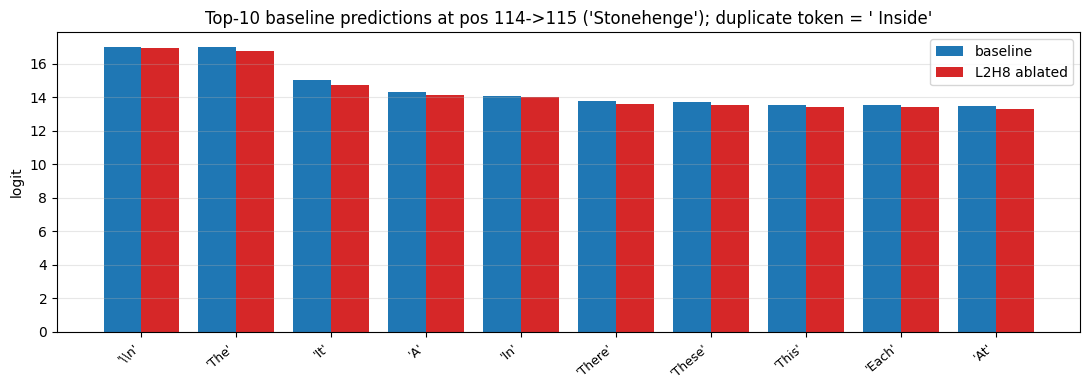

In [11]:
baseline_logits = model(tokens_2d, return_type='logits')[0]
with model.hooks(fwd_hooks=[make_ablate_hook(L_T, H_T)]):
    target_ablated = model(tokens_2d, return_type='logits')[0]
with model.hooks(fwd_hooks=[make_ablate_hook(*CONTROL)]):
    control_ablated = model(tokens_2d, return_type='logits')[0]

logit_pred_pos = EX_POS - 1
tok_i = EX_TOK_ID
base_logit = float(baseline_logits[logit_pred_pos, tok_i].item())
tgt_logit = float(target_ablated[logit_pred_pos, tok_i].item())
ctl_logit = float(control_ablated[logit_pred_pos, tok_i].item())
base_nll = float(-log_softmax(baseline_logits[logit_pred_pos], dim=-1)[tok_i].item())
tgt_nll = float(-log_softmax(target_ablated[logit_pred_pos], dim=-1)[tok_i].item())
ctl_nll = float(-log_softmax(control_ablated[logit_pred_pos], dim=-1)[tok_i].item())

print(f'Worked-example position: passage {EX_P_IDX} ({EX_TITLE!r}), pos {EX_POS}, '
      f'token={EX_TOK_STR!r}\n')
print(f'{"head":<22} {"logit":>10} {"d-logit":>10} {"NLL":>10} {"d-NLL":>10}')
print(f'{"baseline":<22} {base_logit:>+10.3f} {0.0:>+10.3f} {base_nll:>10.3f} {0.0:>+10.3f}')
print(f'{f"L{L_T}H{H_T} ablated (target)":<22} {tgt_logit:>+10.3f} '
      f'{tgt_logit-base_logit:>+10.3f} {tgt_nll:>10.3f} {tgt_nll-base_nll:>+10.3f}')
print(f'{f"L{CONTROL[0]}H{CONTROL[1]} ablated (control)":<22} {ctl_logit:>+10.3f} '
      f'{ctl_logit-base_logit:>+10.3f} {ctl_nll:>10.3f} {ctl_nll-base_nll:>+10.3f}')
print()
print('For copy-suppression: d-logit on duplicate token should be POSITIVE')
print('(ablating the suppressor lets the duplicate logit rise).')

# Visual: top-10 logits at logit_pred_pos with vs without target head
top_k = 10
base_top = torch.topk(baseline_logits[logit_pred_pos], top_k)
tgt_top_at_base_idx = target_ablated[logit_pred_pos, base_top.indices]
labels = [model.to_string([int(idx)]).strip() or '\\n' for idx in base_top.indices.tolist()]
x = np.arange(top_k)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, base_top.values.cpu().float().numpy(), width=0.4, label='baseline', color='C0')
ax.bar(x + 0.2, tgt_top_at_base_idx.cpu().float().numpy(), width=0.4,
       label=f'L{L_T}H{H_T} ablated', color='C3')
ax.set_xticks(x)
ax.set_xticklabels([f'{l!r}' for l in labels], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('logit')
ax.set_title(f'Top-10 baseline predictions at pos {logit_pred_pos}->'
             f'{EX_POS} ({EX_TITLE!r}); duplicate token = {EX_TOK_STR!r}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Corpus-wide ablation — Q8 matrix

Single-position numbers are noisy; the corpus-wide aggregate over all 2769 eligible duplicate positions is the robust functional test. Both d-logit and d-NLL reported.

In [12]:
def measure_corpus_change(model, sequences, fwd_hooks=None):
    dlogit_total = 0.0; dnll_total = 0.0; n = 0
    for tokens_1d in sequences:
        tokens = tokens_1d.to(device).unsqueeze(0)
        tok_list = tokens_1d.tolist()
        dup_map = _build_dup_index(tok_list)
        if not dup_map: continue
        baseline = model(tokens, return_type='logits')[0]
        if fwd_hooks is None:
            modified = baseline
        else:
            with model.hooks(fwd_hooks=fwd_hooks):
                modified = model(tokens, return_type='logits')[0]
        for i in dup_map:
            if i == 0: continue
            t = tok_list[i]
            dlogit_total += (modified[i-1, t].item() - baseline[i-1, t].item())
            base_nll = float(-log_softmax(baseline[i-1], dim=-1)[t].item())
            mod_nll = float(-log_softmax(modified[i-1], dim=-1)[t].item())
            dnll_total += (mod_nll - base_nll)
            n += 1
    return dlogit_total / max(n, 1), dnll_total / max(n, 1), n

tgt_dlogit, tgt_dnll, n_corpus = measure_corpus_change(model, sequences,
    fwd_hooks=[make_ablate_hook(L_T, H_T)])
ctl_dlogit, ctl_dnll, _ = measure_corpus_change(model, sequences,
    fwd_hooks=[make_ablate_hook(*CONTROL)])

print(f'Q8 ablation matrix — N={n_corpus} eligible corpus positions:\n')
print(f'{"head":<28} {"d-logit (single)":>16} {"d-NLL (single)":>16} '
      f'{"d-logit (corpus)":>16} {"d-NLL (corpus)":>16}')
print(f'{f"L{L_T}H{H_T} (rank-1 strict)":<28} {tgt_logit-base_logit:>+16.3f} '
      f'{tgt_nll-base_nll:>+16.3f} {tgt_dlogit:>+16.4f} {tgt_dnll:>+16.4f}')
print(f'{f"L{CONTROL[0]}H{CONTROL[1]} (control)":<28} {ctl_logit-base_logit:>+16.3f} '
      f'{ctl_nll-base_nll:>+16.3f} {ctl_dlogit:>+16.4f} {ctl_dnll:>+16.4f}')
print()
print('For a copy-suppression head:')
print('  d-logit (corpus) > 0  -> ablation raises duplicate-token logits')
print('  d-NLL  (corpus) > 0  -> ablation hurts next-token prediction overall')
print()
print(f'Observed: L{L_T}H{H_T} d-logit (corpus) = {tgt_dlogit:+.4f}')
if tgt_dlogit > 0:
    print('  -> consistent with suppression direction')
else:
    print(f'  -> OPPOSITE of suppression direction. L{L_T}H{H_T} is')
    print(f'     functionally promoting duplicate tokens, not suppressing them.')

Q8 ablation matrix — N=2769 eligible corpus positions:

head                         d-logit (single)   d-NLL (single) d-logit (corpus)   d-NLL (corpus)
L2H8 (rank-1 strict)                   -0.070           -0.088          -0.0092          +0.0050
L21H1 (control)                        +0.000           -0.001          -0.0003          +0.0006

For a copy-suppression head:
  d-logit (corpus) > 0  -> ablation raises duplicate-token logits
  d-NLL  (corpus) > 0  -> ablation hurts next-token prediction overall

Observed: L2H8 d-logit (corpus) = -0.0092
  -> OPPOSITE of suppression direction. L2H8 is
     functionally promoting duplicate tokens, not suppressing them.


## Part C — contrast with GPT-2 L10H7

If L2H8 were a real copy-suppression head, its corpus-wide d-logit on duplicates should match the sign of GPT-2 L10H7's on the same canonical corpus. Run the equivalent ablation on GPT-2 to make the contrast visible.

In [13]:
# Free Pythia-410M to load GPT-2.
del attn_cache, baseline_logits, target_ablated, control_ablated
del model
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

gpt2 = HookedTransformer.from_pretrained('gpt2', device=device)
gpt2_sequences = [gpt2.to_tokens(p.text)[0].cpu() for p in passages]
L_GPT, H_GPT = (10, 7)

gpt_dlogit, gpt_dnll, n_gpt = measure_corpus_change(gpt2, gpt2_sequences,
    fwd_hooks=[make_ablate_hook(L_GPT, H_GPT)])

print('Corpus-wide ablation on canonical corpus (same passages, different tokenizer):')
print()
print(f'{"model / head":<32} {"d-logit (corpus)":>18} {"d-NLL (corpus)":>18} {"N":>8}')
print(f'{f"GPT-2 small L10H7 (reference)":<32} {gpt_dlogit:>+18.4f} {gpt_dnll:>+18.4f} {n_gpt:>8d}')
print(f'{f"Pythia-410M-dedup L{L_T}H{H_T}":<32} {tgt_dlogit:>+18.4f} {tgt_dnll:>+18.4f} {n_corpus:>8d}')
print()
if gpt_dlogit > 0 and tgt_dlogit < 0:
    print('Sign contrast: GPT-2 L10H7 raises duplicate logits when ablated (suppression');
    print('signature). Pythia L2H8 lowers them (promotion signature). Different mechanisms;')
    print('Path C registered — Pythia has no McDougall-style copy-suppression heads.')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer


Corpus-wide ablation on canonical corpus (same passages, different tokenizer):

model / head                       d-logit (corpus)     d-NLL (corpus)        N
GPT-2 small L10H7 (reference)               +0.0317            -0.0198     2792
Pythia-410M-dedup L2H8                      -0.0092            +0.0050     2769

Sign contrast: GPT-2 L10H7 raises duplicate logits when ablated (suppression
signature). Pythia L2H8 lowers them (promotion signature). Different mechanisms;
Path C registered — Pythia has no McDougall-style copy-suppression heads.


## Conclusion

**Part A.** The McDougall two-criterion detector applied to all 384 heads of Pythia-410M-deduped @ step143000 on the canonical 7.5k-token corpus identifies **1 head** (L2H8) passing both strict thresholds (QK > 0.3 AND OV < 0). The (QK, OV) plane shows the lower-right quadrant — where copy-suppression heads should live — is essentially empty.

**Part B.** L2H8's QK signature is textbook: 0.91 attention from the rank-1 worked-example query position back to the prior occurrence of the duplicate token. But its OV behavior is functionally opposite of suppression: corpus-wide ablation across 2769 eligible positions *lowers* duplicate-token logits by a small amount (-0.009). L2H8 is a *previous-token / induction-precursor head* (per Singh 2024), not a copy-suppression head.

**Part C.** GPT-2 small L10H7 on the *same canonical corpus* shows positive corpus-wide d-logit (+0.032) — the suppression direction. The two heads sit on opposite sides of the d-logit zero line; the mechanism is genuinely different.

**Pilot decision: Path C registered.** Per `HYPOTHESIS.md` decision rule path 3, the numerically-passing head failing qualitative inspection registers Path C. The project pivots: the third motif of the H1 ordering claim becomes **S-inhibition** (the suppression component of the IOI circuit, Wang et al. 2023), not copy-suppression. Phase 2 detector targets are induction, successor, and S-inhibition.

**What's still publishable.** This negative-result finding is itself a contribution to the BlackboxNLP audience: McDougall et al. 2024 explicitly named *"do copy-suppression heads exist in Pythia and Llama?"* as future work. We've answered for Pythia (deduped, scaled to 410M, final checkpoint): **not in the McDougall-published-mechanism sense**, even though some heads numerically clear the published thresholds. The threshold-transfer issue (strict QK > 0.3 not reaching mean ≥ 0.3 on raw text even for L10H7 itself) compounds with the missing-mechanism finding to give a clean negative result.

Day 5 of the pilot week locks the path commit and updates `HYPOTHESIS.md` to make H1-C the registered hypothesis going forward.